In [ ]:
import pandas as pd



In [16]:
def load_csv(file):
    try:
        return pd.read_csv(
            file,
            engine="python",
            on_bad_lines="skip",
            encoding="utf-8"
        )
    except:
        return pd.read_csv(
            file,
            engine="python",
            on_bad_lines="skip",
            encoding="latin1"
        )

orders = pd.read_csv("orders_dataset.csv", engine="python")
order_items = pd.read_csv("order_items_dataset.csv", engine="python", on_bad_lines="skip")
payments = pd.read_csv("order_payments_dataset.csv", engine="python")
reviews = pd.read_csv("order_reviews_dataset.csv", engine="python")
products = pd.read_csv("products_dataset.csv", engine="python")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [17]:
#revenue
payment_per_order = payments.groupby('order_id')['payment_value'].sum().reset_index()
#num_products
num_products = order_items.groupby('order_id')['product_id'].count().reset_index()
num_products.rename(columns={'product_id': 'num_products_sold'}, inplace=True)

#avg_price
avg_price = order_items.groupby('order_id')['price'].mean().reset_index()
avg_price.rename(columns={'price': 'avg_price'}, inplace=True)

# total_price
total_price = order_items.groupby('order_id')['price'].sum().reset_index()
total_price.rename(columns={'price': 'total_price'}, inplace=True)

In [18]:
#review
review = reviews.groupby('order_id')['review_score'].mean().reset_index()

##Merge Datasets

In [19]:
data = orders.copy()

data = data.merge(payment_per_order, on='order_id', how='left')
data = data.merge(num_products, on='order_id', how='left')
data = data.merge(avg_price, on='order_id', how='left')
data = data.merge(total_price, on='order_id', how='left')
data = data.merge(review, on='order_id', how='left')

In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   payment_value                  99440 non-null  float64
 9   num_products_sold              98666 non-null  float64
 10  avg_price                      98666 non-null  float64
 11  total_price                    98666 non-null  float64
 12  review_score                   98673 non-null 

##Feature Engineering

In [21]:
# conver dataes
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'], errors='coerce')

data['order_delivered_customer_date'] = pd.to_datetime(
    data['order_delivered_customer_date'], errors='coerce'
)



In [22]:
# create delivery_time
data['delivery_time'] = (
    data['order_delivered_customer_date'] - data['order_purchase_timestamp']
).dt.days


In [23]:
# create date features
data['day_of_week'] = data['order_purchase_timestamp'].dt.dayofweek
data['month'] = data['order_purchase_timestamp'].dt.month



In [24]:
# handeling missing values
data['delivery_time'] = data['delivery_time'].fillna(data['delivery_time'].median())
data['review_score'] = data['review_score'].fillna(data['review_score'].median())

data['num_products_sold'] = data['num_products_sold'].fillna(1)
data['avg_price'] = data['avg_price'].fillna(data['avg_price'].median())
data['total_price'] = data['total_price'].fillna(data['total_price'].median())
data['payment_value'] = data['payment_value'].fillna(0)


##Create the target (Revenue)

In [25]:
y = data['payment_value']

In [26]:
data.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value,num_products_sold,avg_price,total_price,review_score,delivery_time,day_of_week,month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71,1.0,29.99,29.99,4.0,8.0,0,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46,1.0,118.70,118.70,4.0,13.0,1,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12,1.0,159.90,159.90,5.0,9.0,2,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,72.20,1.0,45.00,45.00,5.0,13.0,5,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,28.62,1.0,19.90,19.90,5.0,2.0,1,2
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00,175.26,1.0,147.90,147.90,4.0,16.0,6,7
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaT,2017-05-09 00:00:00,65.95,1.0,49.90,49.90,2.0,10.0,1,4
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00,75.16,1.0,59.99,59.99,5.0,9.0,1,5
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00,35.95,1.0,19.90,19.90,1.0,9.0,0,1
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00,169.76,1.0,149.99,149.99,5.0,18.0,5,7


In [27]:
data .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  object        
 8   payment_value                  99441 non-null  float64       
 9   num_products_sold              99441 non-null  float64       
 10  avg_price                      99441 non-null  float64       
 11  total_price    

##Feature Selection

In [28]:
features = [
    'num_products_sold',
    'avg_price',
    'review_score',
    'delivery_time',
    'day_of_week',
    'month'
]

In [29]:
#review_score feature Handeling
data['review_score'] = data['review_score'].fillna(data['review_score'].median())

##Encoding

In [30]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['order_status'] = le.fit_transform(data['order_status'])

features.append('order_status')

##Prepare the model

In [31]:
X = data[features]

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

##Building ML Model

In [35]:
#Apply StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [36]:
#RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [37]:
#LinearRegression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [38]:
#GradientBoost
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

In [39]:
#xgboost
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

##Building Deep learning Models

In [ ]:
#Apply StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [40]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten

In [41]:
#ANN


model_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

model_ann.compile(
    optimizer='adam',
    loss='mse'
)

model_ann.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

y_pred_ann = model_ann.predict(X_test).flatten()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 13331.8145
Epoch 2/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 5215.1421
Epoch 3/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 4662.5698
Epoch 4/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4029.7654
Epoch 5/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3561.2437
Epoch 6/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3190.5642
Epoch 7/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2987.2939
Epoch 8/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2821.6880
Epoch 9/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 2664.5481
Epoch 10/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 2588.3755
Epoch 11/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2509.1289
Epoch 12/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2413.9670
Epoch 13/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2412.2180
Epoch 14/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 2362.17

In [42]:
#CNN
# reshape
X_train_cnn = X_train.reshape(-1, X_train.shape[1], 1)
X_test_cnn = X_test.reshape(-1, X_test.shape[1], 1)

model_cnn = Sequential([
    Conv1D(filters=32, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], 1)),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_cnn.compile(
    optimizer='adam',
    loss='mse'
)

model_cnn.fit(
    X_train_cnn, y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)

y_pred_cnn = model_cnn.predict(X_test_cnn).flatten()

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 17393.1504
Epoch 2/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 5584.7266
Epoch 3/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5336.9531
Epoch 4/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 5201.7300
Epoch 5/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 5026.8052
Epoch 6/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 4722.9663
Epoch 7/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 4285.8843
Epoch 8/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3881.2666
Epoch 9/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3587.3704
Epoch 10/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 3392.5664
Epoch 11/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - loss: 3282.4844
Epoch 12/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3185.9712
Epoch 13/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3105.3098
Epoch 14/20
2486/2486 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 3036.76

In [43]:
#Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate(name, y_test, y_pred):
    print(f"\n===== {name} =====")
    print("MAE :", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2  :", r2_score(y_test, y_pred))

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Random Forest", y_test, y_pred_rf)
evaluate("Gradient Boosting", y_test, y_pred_gb)
evaluate("XGBoost", y_test, y_pred_xgb)
evaluate("ANN", y_test, y_pred_ann)
evaluate("CNN", y_test, y_pred_cnn)


===== Linear Regression =====
MAE : 17.901789264664096
RMSE: 72.3572547249699
R2  : 0.8906340535378943

===== Random Forest =====
MAE : 10.55790935061924
RMSE: 53.23191940387732
R2  : 0.9408081102449666

===== Gradient Boosting =====
MAE : 10.540684879953462
RMSE: 42.47621190387287
R2  : 0.96231144289474

===== XGBoost =====
MAE : 12.29837185535875
RMSE: 68.2834231812356
R2  : 0.9026023398801352

===== ANN =====
MAE : 11.245686471689654
RMSE: 48.23221868192009
R2  : 0.9514049052397333

===== CNN =====
MAE : 13.691313287974113
RMSE: 51.99100397450603
R2  : 0.943535646308475


##Visualization

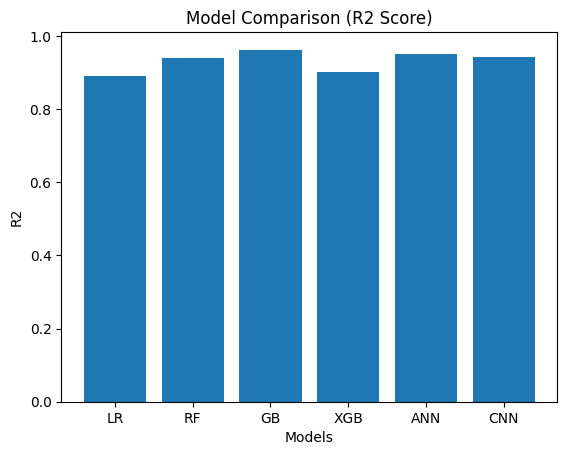

In [45]:
import matplotlib.pyplot as plt

models = ['LR', 'RF', 'GB', 'XGB', 'ANN', 'CNN']

r2 = [0.8906,  0.9408,  0.9623,0.9026,0.9514,0.9435]

plt.figure()
plt.bar(models, r2)
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2")
plt.show()

##Sentiment Model

In [ ]:
#Sentiment Model



##Hybrid Model

In [ ]:
#Hybrid Model
